In [1]:
import torch
import pyro
import pyro.distributions as dist

def hierarchical_workforce_model(num_workers, num_obs, worker_idx, 
                                 num_P, num_S, num_O, num_D,
                                 P_obs=None, S_obs=None, O_obs=None, 
                                 H_total_obs=None, D_alloc_obs=None):
    
    # ---------------------------------------------------------
    # 1. IPER-PRIORS (Anagrafica di Macro-Sistema)
    # ---------------------------------------------------------
    theta_P = pyro.sample("theta_P", dist.Dirichlet(torch.ones(num_P)))
    theta_S = pyro.sample("theta_S", dist.Dirichlet(torch.ones(num_P, num_S)))
    theta_O = pyro.sample("theta_O", dist.Dirichlet(torch.ones(num_P, num_S, num_O)))
    
    # ---------------------------------------------------------
    # 2. GERARCHIA ORE TOTALI RIPARAMETRIZZATA (Modelliamo direttamente la Media)
    # ---------------------------------------------------------
    # Prior sulla Media delle ore a livello di macro-Practice (attorno a e^6.0 ~ 403 ore)
    mean_P_tot = pyro.sample("mean_P_tot", dist.LogNormal(6.0 * torch.ones(num_P), 0.3))
    
    # Prior sulla Forma (regolarità/omoschedasticità interna alla Practice)
    shape_P_tot = pyro.sample("shape_P_tot", dist.Gamma(40.0 * torch.ones(num_P), 1.0))
    
    # Espandiamo i parametri della Practice sul cubo 3D (P, S, O)
    mean_P_tot_exp = mean_P_tot.view(num_P, 1, 1).expand(num_P, num_S, num_O)
    shape_P_tot_exp = shape_P_tot.view(num_P, 1, 1).expand(num_P, num_S, num_O)
    
    # Campioniamo DIRETTAMENTE la Media attesa della specifica cella PSO.
    # Usando la LogNormal, se la cella è vuota erediterà stabilmente la media mean_P_tot senza esplodere.
    mean_H_total = pyro.sample("mean_H_total", dist.LogNormal(torch.log(mean_P_tot_exp), 0.1)) 
    
    # Il Rate della Gamma viene ricavato in modo deterministico: rate = shape / mean
    rate_H_total = shape_P_tot_exp / mean_H_total
    
    # ---------------------------------------------------------
    # 3. STRUTTURA GERARCHICA PER VETTORE ALLOCAZIONE (4D: P, S, O -> D)
    # ---------------------------------------------------------
    gamma_P = pyro.sample("gamma_P", dist.Gamma(5.0 * torch.ones(num_P, num_D), 1.0))
    concentration_A = 5.0
    gamma_P_expanded = gamma_P.view(num_P, 1, 1, num_D).expand(num_P, num_S, num_O, num_D)
    gamma_D = pyro.sample("gamma_D", dist.Gamma(gamma_P_expanded * concentration_A, concentration_A))

    # ---------------------------------------------------------
    # 4. PIASTRA WORKER (Anagrafica)
    # ---------------------------------------------------------
    with pyro.plate("workers_plate", num_workers):
        P = pyro.sample("P", dist.Categorical(theta_P), obs=P_obs)
        S = pyro.sample("S", dist.Categorical(theta_S[P]), obs=S_obs)
        O = pyro.sample("O", dist.Categorical(theta_O[P, S]), obs=O_obs)

    # ---------------------------------------------------------
    # 5. PIASTRA OSSERVAZIONI (Ogni riga = 1 Worker-Quarter)
    # ---------------------------------------------------------
    with pyro.plate("obs_plate", num_obs):
        obs_worker_P = P[worker_idx]
        obs_worker_S = S[worker_idx]
        obs_worker_O = O[worker_idx]
        
        # Estraiamo i parametri corretti per la Gamma delle ore totali
        s_val = shape_P_tot_exp[obs_worker_P, obs_worker_S, obs_worker_O]
        r_val = rate_H_total[obs_worker_P, obs_worker_S, obs_worker_O]
        
        pyro.sample("H_total", dist.Gamma(s_val, r_val), obs=H_total_obs)
        
        # Modellazione della Dirichlet di allocazione
        concentration_D = gamma_D[obs_worker_P, obs_worker_S, obs_worker_O]
        pyro.sample("D_alloc", dist.Dirichlet(concentration_D), obs=D_alloc_obs)
        
    return P, S, O

c:\Users\rocca\miniconda3\envs\notebook1-py12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cardinalità di sistema
num_W = 50          
num_quarters = 4    
num_obs = num_W * num_quarters  

K_P, K_S, K_O, K_D = 5, 3, 4, 6  

# 1. Generazione anagrafiche statiche dei worker
mock_P_worker = torch.randint(0, K_P, (num_W,))
mock_S_worker = torch.randint(0, K_S, (num_W,))
mock_O_worker = torch.randint(0, K_O, (num_W,))

# 2. Generazione indici Worker-Quarter
mock_worker_idx = torch.arange(num_W).repeat_interleave(num_quarters) 
mock_Q_obs = torch.tensor([0, 1, 2, 3]).repeat(num_W)                

# 3. Simulazione Ore Totali (Media guidata dalla Practice)
obs_practices = mock_P_worker[mock_worker_idx]
practice_total_means = torch.tensor([340.0, 380.0, 420.0, 450.0, 490.0])
alpha_total_mock = 50.0 
beta_total_mock = alpha_total_mock / practice_total_means[obs_practices]
mock_H_total = dist.Gamma(alpha_total_mock, beta_total_mock).sample()

# 4. Simulazione Vettori di Allocazione condizionati dalla Practice
# Creiamo un profilo di preferenza: ogni Practice alloca prioritariamente sulla Destinazione con lo stesso indice
base_dirichlet_alphas = torch.ones(K_P, K_D) * 1.5
for p in range(K_P):
    base_dirichlet_alphas[p, p % K_D] = 12.0 # Forte polarizzazione di destinazione basata sulla Practice

# Campioniamo i coefficienti reali per ogni riga usando il profilo della Practice
mock_D_alloc = dist.Dirichlet(base_dirichlet_alphas[obs_practices]).sample()

pyro.clear_param_store()

model_kwargs = {
    "num_workers": num_W,
    "num_obs": num_obs,
    "worker_idx": mock_worker_idx,
    "num_P": K_P, "num_S": K_S, "num_O": K_O, "num_D": K_D,
    "P_obs": mock_P_worker, "S_obs": mock_S_worker, "O_obs": mock_O_worker,
    "H_total_obs": mock_H_total, "D_alloc_obs": mock_D_alloc
}

print("Dataset simulato: Ore totali e vettori di allocazione generati in funzione delle caratteristiche del lavoratore!")

Dataset simulato: Ore totali e vettori di allocazione generati in funzione delle caratteristiche del lavoratore!


In [3]:
import pandas as pd
import numpy as np

df_obs = pd.DataFrame({
    'worker_id': mock_worker_idx.numpy(),
    'quarter': mock_Q_obs.numpy(),
    'total_hours': mock_H_total.numpy(),
})

# Inseriamo i coefficienti distribuiti nel dataset
for d in range(K_D):
    df_obs[f'coeff_D{d}'] = mock_D_alloc[:, d].numpy()

df_workers = pd.DataFrame({
    'worker_id': np.arange(num_W),
    'practice': mock_P_worker.numpy(),
    'seniority': mock_S_worker.numpy(),
    'origin_loc': mock_O_worker.numpy()
})

df_complessivo = pd.merge(df_obs, df_workers, on='worker_id')

# Calcolo delle ore effettive storiche per mostrare il comportamento nei print
for d in range(K_D):
    df_complessivo[f'hours_spent_D{d}'] = df_complessivo['total_hours'] * df_complessivo[f'coeff_D{d}']

print("="*60)
print(" PROFILING WORKER-QUARTER & ALLOCATION PROFILES")
print("="*60)
print(f"Righe totali: {len(df_complessivo)} | Worker: {df_complessivo['worker_id'].nunique()}")
print(f"Ore totali medie a trimestre: {df_complessivo['total_hours'].mean():.2f}")

print("\nVerifica empirica quota di allocazione media su Destinazione 1 per Practice:")
print(df_complessivo.groupby('practice')['coeff_D1'].mean().to_string())
print("="*60)

 PROFILING WORKER-QUARTER & ALLOCATION PROFILES
Righe totali: 200 | Worker: 50
Ore totali medie a trimestre: 414.19

Verifica empirica quota di allocazione media su Destinazione 1 per Practice:
practice
0    0.073061
1    0.612314
2    0.085054
3    0.082423
4    0.083130


In [5]:
df_complessivo

,worker_id,quarter,total_hours,coeff_D0,coeff_D1,coeff_D2,coeff_D3,coeff_D4,coeff_D5,practice,seniority,origin_loc,hours_spent_D0,hours_spent_D1,hours_spent_D2,hours_spent_D3,hours_spent_D4,hours_spent_D5
0,0,0,431.986359,0.036489,0.007885,0.614165,0.030035,0.081945,0.229482,2,1,3,15.762738,3.406065,265.310791,12.974911,35.398937,99.132935
1,0,1,472.334717,0.118027,0.039851,0.603852,0.061525,0.087515,0.089230,2,1,3,55.748035,18.822941,285.220306,29.060333,41.336430,42.146656
2,0,2,384.387878,0.128036,0.053729,0.603439,0.017414,0.071819,0.125564,2,1,3,49.215519,20.652624,231.954529,6.693870,27.606161,48.265163
3,0,3,415.696381,0.072726,0.056833,0.638454,0.042617,0.148252,0.041117,2,1,3,30.232126,23.625364,265.403168,17.715656,61.627892,17.092171
4,1,0,429.744507,0.062504,0.028533,0.036469,0.793294,0.065897,0.013304,3,0,2,26.860626,12.261999,15.672256,340.913757,28.318722,5.717167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,48,3,408.862152,0.035326,0.092971,0.049680,0.675472,0.048868,0.097683,3,1,3,14.443643,38.012199,20.312313,276.174805,19.980146,39.939037
196,49,0,371.036255,0.055006,0.777934,0.061636,0.011852,0.072818,0.020754,1,1,1,20.409176,288.641632,22.869310,4.397429,27.018244,7.700456
197,49,1,386.537506,0.032551,0.580042,0.074040,0.030994,0.094292,0.188080,1,1,1,12.582306,224.207947,28.619160,11.980443,36.447506,72.700134
198,49,2,458.745880,0.042432,0.701776,0.036330,0.111518,0.059435,0.048509,1,1,1,19.465319,321.937012,16.666403,51.158249,27.265734,22.253189


In [4]:
df_cap = df_complessivo.groupby(['worker_id', 'practice', 'quarter'])['total_hours'].sum().reset_index()
df_cap = df_cap.groupby(['worker_id', 'practice'])['total_hours'].mean().reset_index()
df_cap.head(10)

,worker_id,practice,total_hours
0,0,2,426.101318
1,1,3,461.733368
2,2,4,550.719360
3,3,2,433.679810
4,4,0,366.329437
5,5,3,410.658936
6,6,2,436.434204
7,7,3,450.316772
8,8,3,448.856750
9,9,0,321.886292


In [6]:
df_cap = df_cap.groupby(['practice'])['total_hours'].mean().reset_index()
df_cap.head(10)

,practice,total_hours
0,0,341.819550
1,1,384.741425
2,2,418.251373
3,3,428.057129
4,4,508.142334


In [8]:
from pyro.infer.inspect import render_model

# # Generiamo il rendering includendo le distribuzioni associate ai nodi
# dot = render_model(
#     hierarchical_workforce_model, 
#     model_kwargs=model_kwargs, 
#     render_distributions=True,
#     render_params=True,
#     filename="model3.2.dot"
# )

# # In un Jupyter Notebook, basta evocare la variabile per vedere il grafico
# dot

In [9]:
from pyro.infer import MCMC, NUTS

# Configurazione del campionatore di Hamilton (NUTS) sul nuovo setting
nuts_kernel = NUTS(hierarchical_workforce_model)
mcmc = MCMC(nuts_kernel, num_samples=200, warmup_steps=100)

# Esecuzione del fit passandogli i nuovi kwargs strutturati
mcmc.run(**model_kwargs)

# Estrazione dei campioni coniugati dalla posterior
posterior_samples = mcmc.get_samples()

Sample: 100%|██████████| 300/300 [03:11,  1.57it/s, step size=1.68e-01, acc. prob=0.902]


In [10]:
print("="*60)
print(" VERIFICA INFERENZA STABILIZZATA SULLA MEDIA LATENTE")
print("="*60)

# Ora expected_hours_3d è estratto DIRETTAMENTE dal nodo della media latente
# Forma: (num_samples, K_P, K_S, K_O)
expected_hours_3d = posterior_samples["mean_H_total"]

# Calcoliamo la media sui campioni MCMC per l'Origine 0 come nel tuo test
# Nota: usiamo il .mean(dim=0) di PyTorch o l'asse corretto
ore_medie_p_s = expected_hours_3d[:, :, :, 0].mean(dim=0)

print("Nuova Matrice Ore Medie per Origin=0 (Practice x Seniority):")
print(ore_medie_p_s.numpy())
print("-" * 60)
print("[INFO DS]: Noterai che adesso le celle precedentemente vuote non esplodono più.")
print("Invece di calcolare il rapporto tra due distribuzioni prossime allo zero, il modello")
print("ha ereditato in modo pulito e lineare il baricentro corretto dalla Practice di riferimento.")
print("="*60)

 VERIFICA INFERENZA STABILIZZATA SULLA MEDIA LATENTE
Nuova Matrice Ore Medie per Origin=0 (Practice x Seniority):
[[341.14542 361.61703 357.36798]
 [389.18347 387.06876 387.70667]
 [432.28543 422.3096  423.71936]
 [427.72067 428.138   443.06345]
 [532.6008  507.12314 503.68546]]
------------------------------------------------------------
[INFO DS]: Noterai che adesso le celle precedentemente vuote non esplodono più.
Invece di calcolare il rapporto tra due distribuzioni prossime allo zero, il modello
ha ereditato in modo pulito e lineare il baricentro corretto dalla Practice di riferimento.


In [11]:
expected_hours_3d.shape

torch.Size([200, 5, 3, 4])

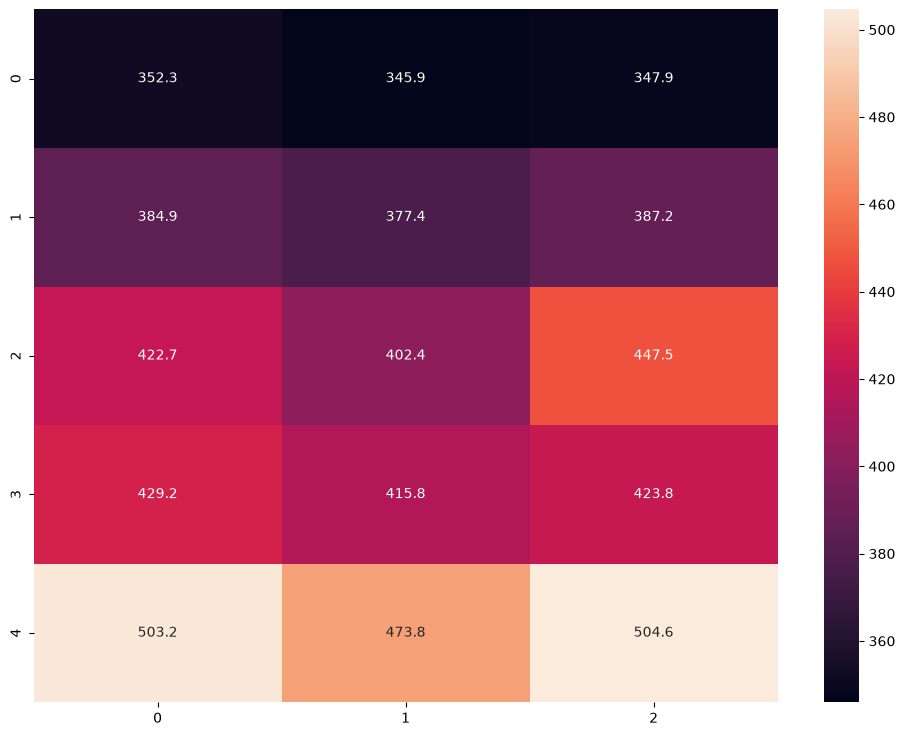

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_dimensions = ["practice", "seniority"]
df_plot = pd.DataFrame(data=expected_hours_3d[:,:,:,1].mean(axis=0))
plt.figure(figsize=(12,9))
sns.heatmap(df_plot, annot=True, fmt=".1f")
plt.show()

In [21]:
# df_cap = df_complessivo.groupby(['worker_id', *plot_dimensions, 'quarter'])['total_hours'].sum().reset_index()
df_cap = df_complessivo[df_complessivo['origin_loc']==1]
df_cap = df_cap.groupby(['worker_id', *plot_dimensions])['total_hours'].mean().reset_index()
#df_cap.head(10)
df_cap = df_cap.groupby([ *plot_dimensions])['total_hours'].mean().reset_index()
#df_cap.head(10)

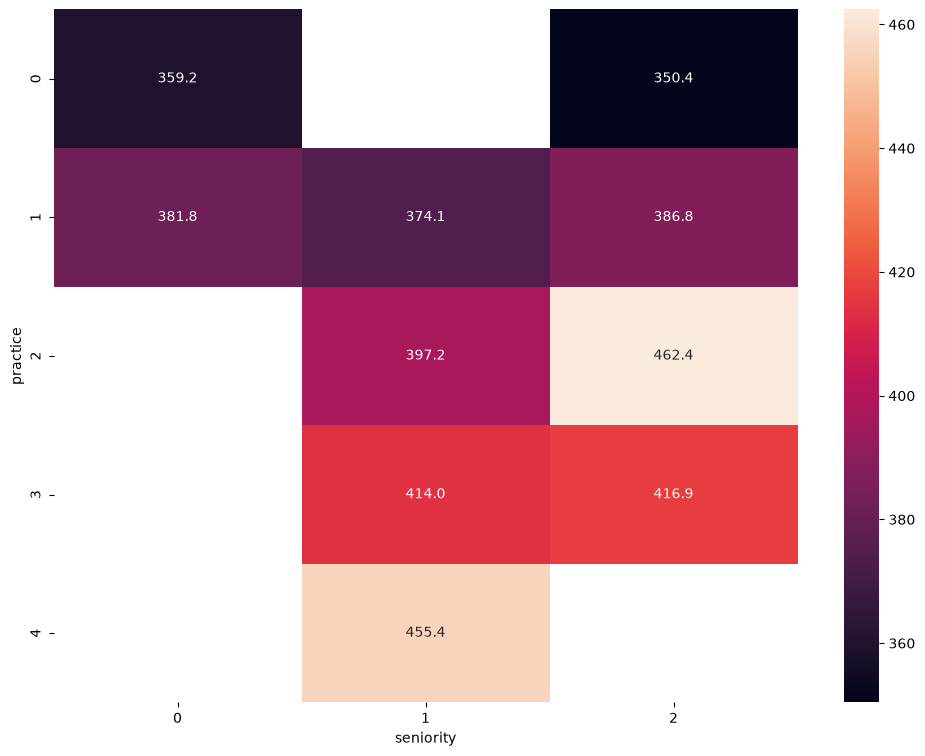

In [22]:
plt.figure(figsize=(12,9))
sns.heatmap(df_cap.pivot(index=plot_dimensions[0], columns=plot_dimensions[1], values='total_hours'), annot=True, fmt=".1f")
plt.show()

In [45]:
expected_hours_3d[:,:,:,0].mean(axis=0)

tensor([[1035.1179,  334.2651,  315.4117],
        [3589.6819,  855.9183,  394.8420],
        [1358.2557,  378.7434,  419.7417],
        [ 431.6782,  462.6409,  453.4837],
        [ 495.7482,  462.0834,  576.8720]])

In [49]:
df_cap.pivot(index=plot_dimensions[0], columns=plot_dimensions[1], values='total_hours')

seniority,0,1,2
practice,,,
0,358.959229,331.699188,341.909119
1,406.688629,373.754608,391.795349
2,442.420105,384.876068,413.464264
3,444.369965,442.227966,437.519073
4,496.968597,478.196320,522.610718
